# Homework 2: Probability Models

BEE 4850/5850

**Name**:

**ID**:

> **Due Date**
>
> Friday, 2/20/26, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to fit some linear regressions to Chicago
    mortality data.
-   Problem 2 asks you to analyze the probability of Cayuga Lake
    freezing using a logistic regression model.
-   Problem 3 asks you to use Poisson regression to predict salamander
    counts based on environmental data.
-   Problem 4 asks you to look at the impact of the gender of hurricane
    names on deaths[1].

[1] Yes, seriously. Ish. Trust me, I know.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [76]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.Registry.update()
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()

  Activating project at `c:\Users\nicho\Documents\hw02-NickZajac56`
    Updating registry at `C:\Users\nicho\.julia\registries\General.toml`
     Project No packages added to or removed from `C:\Users\nicho\Documents\hw02-NickZajac56\Project.toml`
    Manifest No packages added to or removed from `C:\Users\nicho\Documents\hw02-NickZajac56\Manifest.toml`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [77]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools
import Pkg; Pkg.add("GLM")
using GLM


   Resolving package versions...
     Project No packages added to or removed from `C:\Users\nicho\Documents\hw02-NickZajac56\Project.toml`
    Manifest No packages added to or removed from `C:\Users\nicho\Documents\hw02-NickZajac56\Manifest.toml`


## Problems

### Problem 1 (6 points)

Let’s revisit the `chicago` dataset from HW1 (found in
`data/chicago.csv`). We will look at the relationship of the potential
predictor variables `pm25median` (the median density of smaller
pollutant particles), `o3median` (the median concentration of O$_3$),
`so2median` (the median concentration of SO$_2$), and `tmpd` (mean daily
temperature) with the variable we would like to predict, `death` (the
number of non-accidental deaths on that day).

#### Problem 1.1

Plot each predictor variable against the response variable (make sure to
include labels and titles for each plot). Describe what you observe
about the bivariate relationships, if one exists (*e.g.* does it look
like they exist, are they linear, positive/negative, etc.) Does a linear
regression seem appropriate from any of these plots? Which predictor do
you think is most appropriate for a linear regression model and why?

#### Problem 1.2

You decide to focus on the relationship between `tmpd` and `death`. Your
classmate suggests that you use a Gaussian-error linear regression
model. Based on this suggestion, calculate the regression coefficients
and error variance. Explain the interpretation of the coefficients that
you obtain **in this specific problem context**.

#### Problem 1.3

Add your fitted regression line and a 90% prediction interval to your
scatterplot of `tmpd` and `death`. Using this and any other diagnostics,
do you agree with the Gaussian-error linear model assumption? Why or why
not?

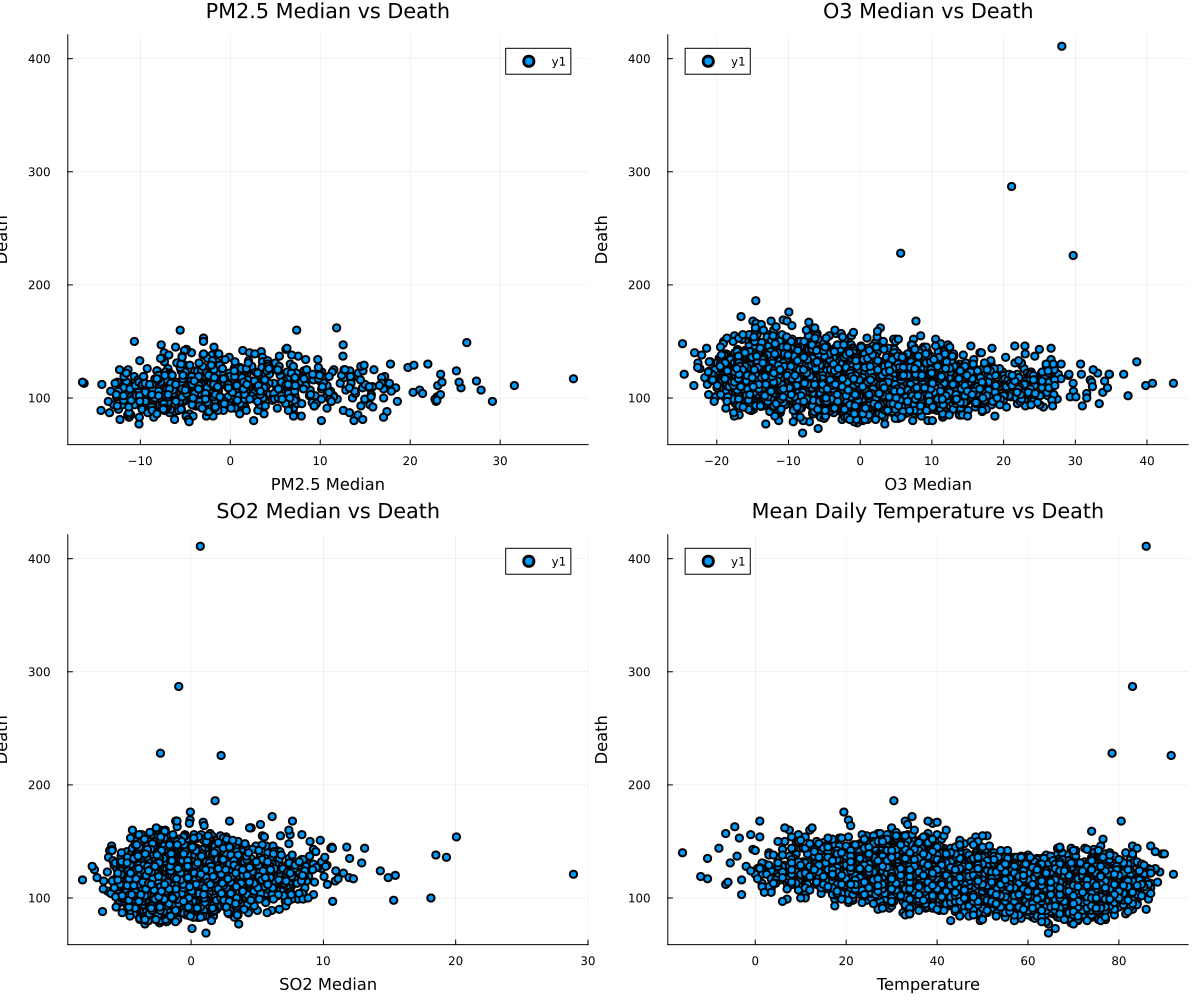

In [78]:
#Problem 1.1

data_chicago = DataFrame(load("data/chicago.csv")) #load data into DataFrame 

death = data_chicago.death

#Plot code

p1 = scatter(data_chicago.pm25median, death, xlabel = "PM2.5 Median", 
    ylabel = "Death", title = "PM2.5 Median vs Death") 

p2 = scatter(data_chicago.o3median, death, xlabel = "O3 Median", 
    ylabel = "Death", title = "O3 Median vs Death") 

p3 = scatter(data_chicago.so2median, death, xlabel = "SO2 Median", 
    ylabel = "Death", title = "SO2 Median vs Death") 

p4 = scatter(data_chicago.tmpd, death, xlabel = "Temperature", 
    ylabel = "Death", title = "Mean Daily Temperature vs Death")

plot(p1, p2, p3, p4, layout=(2,2), size=(1200,1000))


In [79]:
x = data_chicago.tmpd
y = data_chicago.death

n = length(y)

# Create design matrix

X = hcat(ones(n), x)

# OLS Code

beta_hat= inv(X'X) * (X'y)

beta_0 = beta_hat[1]
beta_1 = beta_hat[2]

# calculate residuals and error variance

y_hat = X * beta_hat

residuals = y - y_hat

sigma_squared = sum(residuals.^2) / (n - 2)

println("Beta 0 (Intercept) is ", beta_0)
println("Beta 1 (Slope) is ", beta_1)
print("Sigma Squared (Error Variance) is ", sigma_squared)

Beta 0 (Intercept) is 129.95705121476817
Beta 1 (Slope) is -0.2896442961500988
Sigma Squared (Error Variance) is 202.31531425938184

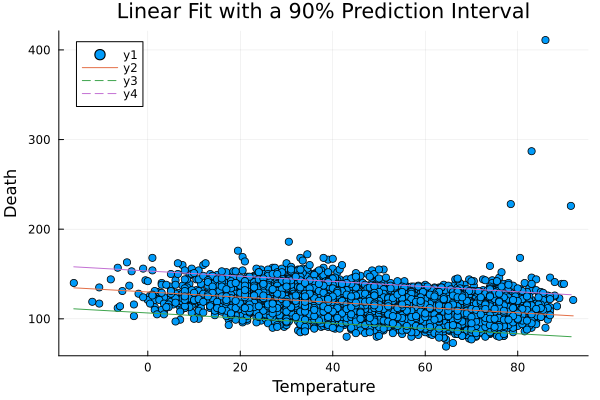

In [80]:
#Problem 1.3

#Linear model code to get regression line and prediction interval

model = lm(@formula(death ~ tmpd), data_chicago)

predicted = predict(model, data_chicago; interval = :prediction, level = 0.90)


#Plot code

p4 = scatter(data_chicago.tmpd, death, xlabel = "Temperature", 
    ylabel = "Death", title = "Linear Fit with a 90% Prediction Interval")

plot!(data_chicago.tmpd, predicted.prediction)
plot!(data_chicago.tmpd, predicted.lower, linestyle=:dash)
plot!(data_chicago.tmpd, predicted.upper, linestyle=:dash)

Problem 1.1

Given the scatterplots above, there does not appear to be a very apparent observable bivariate relationship. The plots for O3 Median and SO2 median are quite dense making it hard to see if there is anything more than a potential weak relationship.  Similarly, it is also difficult to spot a relationship with temperature.  There may be a slightly negative relationship between temperature and death, but it is hard to tell given the density of the graph.  PM2.5 is the predictor that I would say is the best candidate for linear regression.  There appears to be a faint positive relationship between PM2.5 concentrations and deaths, however more statistical analysis is needed.  There is enough linearity that linear regression does seem appropriate for this plot and there are also no outliers, unlike with the other three predictors, and it does show the most linearity of the four predictors.


Problem 1.2

Beta 0 (Intercept) is 129.96 

Beta 1 (Slope) is -0.29 

Sigma Squared (Error Variance) is 202.32

Beta 0 is our estimated intercept.  In this specific problem context, this is the estimated number of deaths when mean daily temperature is 0 degrees Fahrenheit.

Beta 1 is our slope.  In this specific problem context, this is the estimated change in deaths for a one degree Fahrenheit increase in mean daily temperature.

Sigma Squared is our error variance.  This is the variability in death counts around the fitted linear relationship with temperature.


Problem 1.3

I do not agree with the Gaussian error linear model assumption.  It does appear to be a reasonable fit from ~0 - 70 degrees Fahrenheit, but around 70 degrees Fahrenheit the data points appear to narrow and maybe start curving up towards increased death counts.  The death counts around 85-90 degrees Fahrenheit look elevated in comparison to death counts at ~60-70 degrees Fahrenheit.  

Moreover, while not a statistical diagnostic, this also just follows reason.  It makes much more sense for deaths to be elevated at more extreme hot and cold temperatures and lower at a more temperature temperature.  I would more expect this data to yield something more quadratic/nonlinear, with the minimum vertex (lowest deaths) at ~65-70 degrees and increasing in death count in either direction from this point.


### Problem 2 (6 points)

This problem is adapted from Example 4.1 and 4.2 in Daniel Wilks’
*Statistical Methods in the Atmospheric Sciences*. Updating the table in
that book, Cayuga Lake has frozen in 1796, 1816, 1856, 1875, 1884, 1904,
1912, 1934, 1961, 1979, and 2015[1]. The probability of whether a severe
enough cold spell to freeze the lake occurs is related to changes in
global mean temperature. The file `data/HadCRUT5.1Analysis_gl.txt`
contains estimates of monthly global mean temperature anomalies (in
$^\circ$ C, relative to the 1961–1990 mean) as well as the annual global
temperature anomaly. You would like to build a model to predict the
probability that Cayuga Lake freezes based on the winter (DJF)
temperature anomaly.

In [81]:
#From below
temp_dat = CSV.read("data/HadCRUT5.1Analysis_gl.txt", delim=" ", 
    ignorerepeated=true, header=false, 
    silencewarnings=true, DataFrame) 

Row,Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,Column11,Column12,Column13,Column14
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64?
1,1850,-0.734,-0.36,-0.627,-0.605,-0.532,-0.352,-0.176,-0.223,-0.394,-0.516,-0.277,-0.322,-0.426
2,1850,54.0,49.0,46.0,49.0,51.0,51.0,54.0,57.0,58.0,57.0,60.0,60.0,missing
3,1851,-0.266,-0.467,-0.641,-0.528,-0.222,-0.207,-0.136,-0.148,-0.146,-0.045,-0.108,-0.248,-0.264
4,1851,60.0,56.0,57.0,56.0,57.0,55.0,56.0,61.0,49.0,52.0,50.0,50.0,missing
5,1852,-0.346,-0.496,-0.567,-0.575,-0.113,-0.077,0.009,-0.149,-0.006,-0.158,-0.275,0.064,-0.224
6,1852,54.0,55.0,57.0,57.0,57.0,60.0,58.0,59.0,55.0,56.0,55.0,58.0,missing
7,1853,-0.204,-0.399,-0.273,-0.401,-0.27,-0.124,-0.072,-0.04,-0.266,-0.373,-0.401,-0.326,-0.262
8,1853,59.0,59.0,58.0,56.0,60.0,60.0,61.0,65.0,64.0,69.0,62.0,65.0,missing
9,1854,-0.403,-0.392,-0.247,-0.327,-0.277,-0.302,-0.162,-0.233,-0.216,-0.099,-0.412,-0.454,-0.294


#### Problem 2.1

Write down a logistic regression model for the probability that Cayuga
Lake freezes in a given winter. Encode the occurrence of freezing as a
1, and non-freezing as 0. Load the temperature data and fit this model.
The format of the data file is a little awkward, as the even rows are
the number of stations (which should be ignored) and have uneven number
of space delimiters. The first 13 columns are the year and the monthly
means; the final column is the annual average (which we don’t want to
use). Another complication is that the (even-numbered) station rows
don’t have an entry in the 14th column. In Julia, you can load the file
with

``` julia
temp_dat = CSV.read("data/HadCRUT5.1Analysis_gl.txt", delim=" ", 
    ignorerepeated=true, header=false, 
    silencewarnings=true, DataFrame) 
```

To simplify the analysis, since we don’t always know whether the lake
froze in the January starting a year or the December ending a year,
let’s assume that the years in which the lake froze correspond to the
winter starting the year (so the DJF mean corresponding to the freezing
in 1884 would include the December from 1883 and the January and
February from 1884). You will only be able to use freezing events
between 1851 and the present day due to the temperature data. Interpret
the coefficients from your model fit **in this specific problem
context**.

#### Problem 2.2

Plot the modeled probability of freezing as a function of the DFJ
temperature anomaly, and how this probability has changed over time.
Does this model seem reasonable? How might you determine this?

#### Problem 2.3

What winter temperature anomaly would be required for less than a 1%
probability of Cayuga Lake freezing?

In [82]:
freeze_years = [1796, 1816, 1856, 1875, 1884, 1904, 1912, 1934, 1961, 1979, 2015]

#Remove odd number rows since they are not of relevance
temp_dat = temp_dat[1:2:end, :]

#Store column values
year = temp_dat[:, 1]
dec = temp_dat[:, 13]
jan = temp_dat[:, 2]
feb = temp_dat[:, 3]

djf = (dec[1:end - 1] .+ jan[2:end] .+ feb[2:end])./3

winter_year = year[2:end]

winter_df = DataFrame(year = winter_year, djf = djf)

winter_df = winter_df[winter_df.year .>= 1851, :]

#Ternary operation to designate freeze years as 1 and everything else as 0
winter_df.freeze = [y in freeze_years ? 1 : 0 for y in winter_df.year]

model_winter = glm(@formula(freeze ~ djf), winter_df, Binomial(),LogitLink())

(model_winter)

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

freeze ~ 1 + djf

Coefficients:
─────────────────────────────────────────────────────────────────────────
                 Coef.  Std. Error      z  Pr(>|z|)  Lower 95%  Upper 95%
─────────────────────────────────────────────────────────────────────────
(Intercept)  -3.01638     0.38505   -7.83    <1e-14   -3.77106   -2.26169
djf          -0.714205    0.912985  -0.78    0.4341   -2.50362    1.07521
─────────────────────────────────────────────────────────────────────────

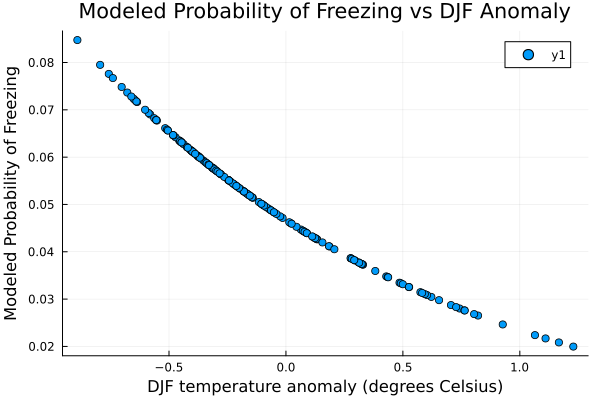

In [97]:
#Plot Code

scatter(winter_df.djf, predict(model_winter), 
xlabel = "DJF temperature anomaly (degrees Celsius)",
ylabel = "Modeled Probability of Freezing", 
title = "Modeled Probability of Freezing vs DJF Anomaly")

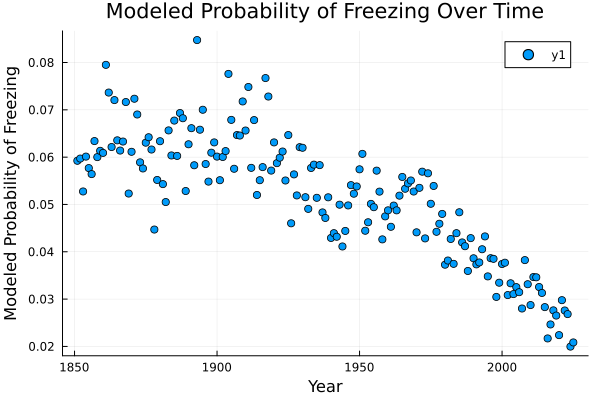

In [84]:
#Plot code

scatter(winter_df.year, predict(model_winter), xlabel = "Year",
ylabel = "Modeled Probability of Freezing", title = "Modeled Probability of Freezing Over Time")

Problem 2.1


The intercept coefficient is -3.016 

The djf coefficient is -0.714


Beta 0 is our estimated intercept.  In this specific problem context, this is the calculated log odds of freezing when DJF is 0 degrees celsius, relative to the 1961 - 1990 mean.  Given the equation of p = e^beta0 / (1 + e^beta0), this results in a proabaility of freezing at djf = 0 of ~4.7%.

Beta 1 is our slope.  In this specific problem context, this is the estimated change in log odds of freezing for a one degree Celsius increase in DJF mean temperature.  Odds ratio is given by e^beta1, so this gives a result of ~0.49, so an increase in one degree celsius DJF mean temperature results decreases the odds of freezing by ~51% (Reduced by 49%, so a 51% reduction).


Problem 2.2

The model seems logicially reasonable, but does not produce statistically significant results.  The results do make pragmatic sense with the Beta1 value showing that an increase in DJF mean temperature decreases the odds of freezing.  The P-value, however, is 0.434 which is very high and does not allow us to reject the null hypothesis that global DJF mean temperatures are unrelated to Cayuga Lake freezing.  Additionally, the confidence interval is quite wide and spans from negative values to positive values (-2.50 to 1.08) which is also not ideal for model reasonability and gives quite a bit of uncertainity.  This wide confidence interval and high P-value likely stems from the limited amount of freezing events throughout the dataset.  So while the model produces reasonable results, there is not a lot of evidence supporting a strong statistical relationship.  


In [85]:
#Set coefficients
beta0 = -3.016
beta1 = -.714

#Log formula and calculations with p = 0.01
logodds_freeze = log(0.01 / (1 - 0.01))

freeze_anomaly = ((logodds_freeze - beta0) / beta1)

print("The winter temperature anomaly that is required for less than
 a one percent probability of Cayuga Lake freezing is ", freeze_anomaly)

The winter temperature anomaly that is required for less than
 a one percent probability of Cayuga Lake freezing is 2.2116524511688933

Problem 2.3

The winter temperature anomaly required for less than 1% probability of Cayuga Lake freezing is 2.21 degrees Celsius.


### Problem 3 (6 points)

The file `data/salamanders.csv` contains counts of salamanders from 47
different plots of the same area in California, as well as the
percentage of ground cover and age of the forest in the plot. You would
like to see if you can use these data to predict the salamander counts
with a Poisson regression.

In [ ]:
#load data but delimit the semicolons
salamander = CSV.read("data/salamanders.csv", DataFrame, delim=";") 


Row,SITE,SALAMAN,PCTCOVER,FORESTAGE
,Int64,Int64,Int64,Int64
1,1,13,85,316
2,2,11,86,88
3,3,11,90,548
4,4,9,88,64
5,5,8,89,43
6,6,7,83,368
7,7,6,83,200
8,8,6,91,71
9,9,5,88,42


#### Problem 3.1

Write down and fit a Poisson regression model for salamander counts
using the percentage of ground cover as a predictor. You may need to
standardize the predictors as they are much larger than the counts,
which you can do using the following function (or its equivalent):

[1] Many of these dates, particularly prior to the 20th century, are
subject to some debate, and would be different depending on the data
source. Nevertheless, let’s use this dataset.

In [87]:
stdz(x) = (x .- mean(x)) / std(x)

#Standardize
salamander.pct_stdz = stdz(salamander.PCTCOVER)

#Model with standardized predictors
poisson_model = glm(@formula(SALAMAN ~ pct_stdz), salamander, Poisson(), LogLink())

println(poisson_model)

#model not using standardized predictors for comparison purposes
poisson_model_notstandard = glm(@formula(SALAMAN ~ PCTCOVER), salamander, Poisson(), LogLink())


StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Poisson{Float64}, LogLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}(GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Poisson{Float64}, LogLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}:

Coefficients:
──────────────────────────────────────────────────────────────
       Coef.  Std. Error     z  Pr(>|z|)  Lower 95%  Upper 95%
──────────────────────────────────────────────────────────────
x1  0.429511    0.158326  2.71    0.0067   0.119198   0.739825
x2  1.15951     0.192887  6.01    <1e-08   0.781454   1.53756
──────────────────────────────────────────────────────────────
, ModelFrame{@NamedTuple{SALAMAN::Vector{Int64}, pct_stdz::Vector{Float64}}, GeneralizedLinearModel}(SALAMAN ~ 1 + pct_stdz, StatsModels.Schema with 2 entries:
  pct_stdz => pct_stdz
  SALAMAN => 

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Poisson{Float64}, LogLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

SALAMAN ~ 1 + PCTCOVER

Coefficients:
────────────────────────────────────────────────────────────────────────────
                  Coef.  Std. Error      z  Pr(>|z|)   Lower 95%   Upper 95%
────────────────────────────────────────────────────────────────────────────
(Intercept)  -1.48196    0.45578     -3.25    0.0011  -2.37527    -0.588645
PCTCOVER      0.0324095  0.00539141   6.01    <1e-08   0.0218425   0.0429764
────────────────────────────────────────────────────────────────────────────

#### Problem 3.2

Plot the expected counts and 90% prediction intervals from your model
(based on 1,000 simulations from the model) along with the data. How
well does the model predict the observed counts? In what ways does it do
a good or bad job?

#### Problem 3.3

Can you improve the model by including forest age as a predictor? How
did you determine whether this helps or does not help with prediction?

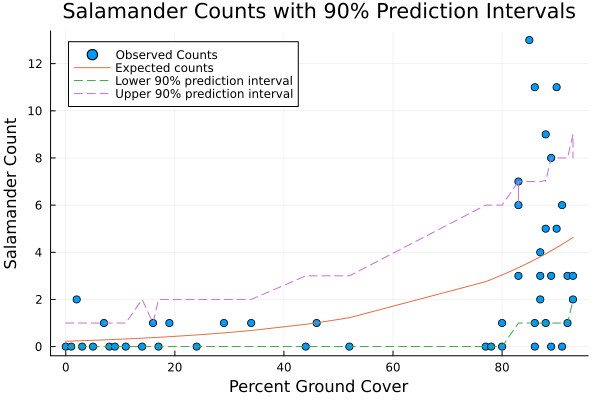

In [88]:
#Predicted counts

pred_sal = predict(poisson_model_notstandard)

n_sims = 1000

#sim 1000 results
sim_matrix = [rand(Poisson(pred_sal[i]), n_sims) for i in 1:length(pred_sal)]

#prediction interval
lower = [quantile(sim_matrix[i], 0.05) for i in 1:length(pred_sal)]
upper = [quantile(sim_matrix[i], 0.95) for i in 1:length(pred_sal)]

#Sort data to make graph clean
sort_3 = sortperm(salamander.PCTCOVER)

pctcover_sorted = salamander.PCTCOVER[sort_3]
salaman_sorted = salamander.SALAMAN[sort_3]

pred_sal_sorted = pred_sal[sort_3]
lower_sorted = lower[sort_3]
upper_sorted = upper[sort_3]

# Plot data
scatter(pctcover_sorted, salaman_sorted, xlabel = "Percent Ground Cover", 
    ylabel = "Salamander Count", title = 
    "Salamander Counts with 90% Prediction Intervals", label = "Observed Counts")

plot!(pctcover_sorted, pred_sal_sorted, label = "Expected counts")

plot!(pctcover_sorted, lower_sorted, linestyle=:dash, label = "Lower 90% prediction interval")
plot!(pctcover_sorted, upper_sorted, linestyle=:dash, label = "Upper 90% prediction interval")

Problem 3.2

The model appears to predict the observed counts reasonably well.  The expected counts follow an increasing trend with more ground cover, which is to be expected and it captures the seemingly nonlinear relationship reasonably as well.  So with that, the model does a good job.  The model does do a relatively bad job at predicting counts when the percent ground cover is large.  This, however, makes sense given the large variability in the data and potential overdispersion.  It would be difficult for a one predictor model to capture the large variability in observed counts that is shown in the upper end of this data.


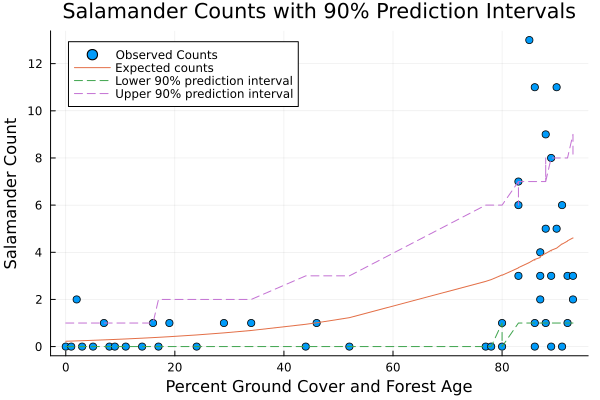

In [89]:
poisson_model_2 = glm(@formula(SALAMAN ~ PCTCOVER + FORESTAGE), salamander, Poisson(), LogLink())


pred_sal2 = predict(poisson_model_2)

n_sims = 1000

#sim 1000 results
sim_matrix2 = [rand(Poisson(pred_sal2[i]), n_sims) for i in 1:length(pred_sal2)]

#prediction interval
lower2 = [quantile(sim_matrix2[i], 0.05) for i in 1:length(pred_sal2)]
upper2 = [quantile(sim_matrix2[i], 0.95) for i in 1:length(pred_sal2)]

#Sort data to make graph clean
sort_3_2 = sortperm(salamander.PCTCOVER)

pctcover_sorted2 = salamander.PCTCOVER[sort_3_2]
salaman_sorted2 = salamander.SALAMAN[sort_3_2]

pred_sal_sorted2 = pred_sal2[sort_3_2]
lower_sorted2 = lower2[sort_3_2]
upper_sorted2 = upper2[sort_3_2]

# Plot data
scatter(pctcover_sorted2, salaman_sorted2, xlabel = "Percent Ground Cover and Forest Age", 
    ylabel = "Salamander Count", title = 
    "Salamander Counts with 90% Prediction Intervals", label = "Observed Counts")

plot!(pctcover_sorted2, pred_sal_sorted2, label = "Expected counts")

plot!(pctcover_sorted2, lower_sorted2, linestyle=:dash, label = "Lower 90% prediction interval")
plot!(pctcover_sorted2, upper_sorted2, linestyle=:dash, label = "Upper 90% prediction interval")

In [90]:
#AIC code


aic_ns = aic(poisson_model_notstandard)
aic_2 = aic(poisson_model_2)

println(aic_ns)
print(aic_2)

210.3639242610706
212.36212742484764

Problem 3.3

Including forest age as a predictor does not improve the model.  I first initially ran another GLM including forest age as a predictor to see if there were any noticable changes in the outputs and plots.  Since there were not, I decided to calculate AIC which is a good way to determine if a model is better based on the maximum log-likelihood and the number of parameters.  The lower the AIC the better, so seeing that adding forest age to the model increased the AIC shows that the models performance did not improve enough to justify adding the extra parameter.  As I've been instructed in previous classes, an AIC of ~2 - 6 indicates a weak preference towards the model with a lower AIC so this is how I determined that I have a weak preference towards the model without forest age as a predictor.

### Problem 4 (7 points)

In 2014, [a paper was published in a prestigious
journal](https://www.pnas.org/doi/10.1073/pnas.1402786111) which claimed
that hurricanes with more feminine names are deadlier than hurricanes
with more masculine names because people take warnings about
female-named hurricanes less seriously[1]. The file
`data/Hurricanes.csv` contains the original data used in this analysis
(note that this dataset excludes Hurricanes Katrina and Audrey because
they were “outliers”). While we won’t replicate the specific analysis in
this paper, let’s use the data to look at this hypothesis.

#### Problem 4.1

One might interpret the hypothesis to claim that the impact of the name
is strengthened by the the more powerful. A measure of hurricane
strength is its minimum pressure (`min_pressure` in the dataset). Fit a
Poisson regression model that predicts deaths (`deaths`) using the
gender of the name (`female`) and minimum pressure (you may need to
standardize the pressure). We use `female` instead of the continuous
measure of the `femininity` of the name as this is highly subjective and
has some weird coding (such as “Sandy” being coded as one of the most
female names).

#### Problem 4.2

Interpret the results by generating 10,000 counterfactual simulations
for hurricanes with male and female names. Plot the expected values and
90% prediction intervals from these two sets of simulations and compare
with the observed storm deaths. Where does the model do well or not
well?

#### Problem 4.3

Does the gender effect size resulting from this model seem reasonable to
you? Draw on qualitative or quantitative assessments to justify your
assessment of reasonableness.

#### Problem 4.4

We can now stop taking this hypothesis seriously. To what extent do you
think the finding could be an artifact of the dataset (e.g. there is no
actual effect, but there are coincidental features of the data that
produce the result that female-named storms are more deadly than
male-named storms)? Justify this conclusion with specific reference to
an exploratory analysis of the data.

In [91]:
#Problem 4.1

hurricane = CSV.read("data/Hurricanes.csv", DataFrame)

stdz(x) = (x .- mean(x)) / std(x)

#standardize hurricane pressure
hurricane.pressure_std = stdz(hurricane.min_pressure)

#model with standarized pressure
model_h = glm(@formula(deaths ~ female + pressure_std), hurricane, Poisson(), LogLink())

println(model_h)

#model with pressure not standarized for comparison
model_h2 = glm(@formula(deaths ~ female + min_pressure), hurricane, Poisson(), LogLink())


StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Poisson{Float64}, LogLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}(GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Poisson{Float64}, LogLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}:

Coefficients:
─────────────────────────────────────────────────────────────────
        Coef.  Std. Error       z  Pr(>|z|)  Lower 95%  Upper 95%
─────────────────────────────────────────────────────────────────
x1   2.41467    0.0508083   47.53    <1e-99   2.31508    2.51425
x2   0.472112   0.0549823    8.59    <1e-17   0.364348   0.579875
x3  -0.719532   0.0217961  -33.01    <1e-99  -0.762252  -0.676813
─────────────────────────────────────────────────────────────────
, ModelFrame{@NamedTuple{deaths::Vector{Int64}, female::Vector{Int64}, pressure_std::Vector{Float64}}, Generaliz

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Poisson{Float64}, LogLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

deaths ~ 1 + female + min_pressure

Coefficients:
──────────────────────────────────────────────────────────────────────────────
                   Coef.  Std. Error       z  Pr(>|z|)   Lower 95%   Upper 95%
──────────────────────────────────────────────────────────────────────────────
(Intercept)   38.8308     1.08872      35.67    <1e-99  36.697      40.9647
female         0.472112   0.0549823     8.59    <1e-17   0.364348    0.579875
min_pressure  -0.0377404  0.00114323  -33.01    <1e-99  -0.0399811  -0.0354997
──────────────────────────────────────────────────────────────────────────────

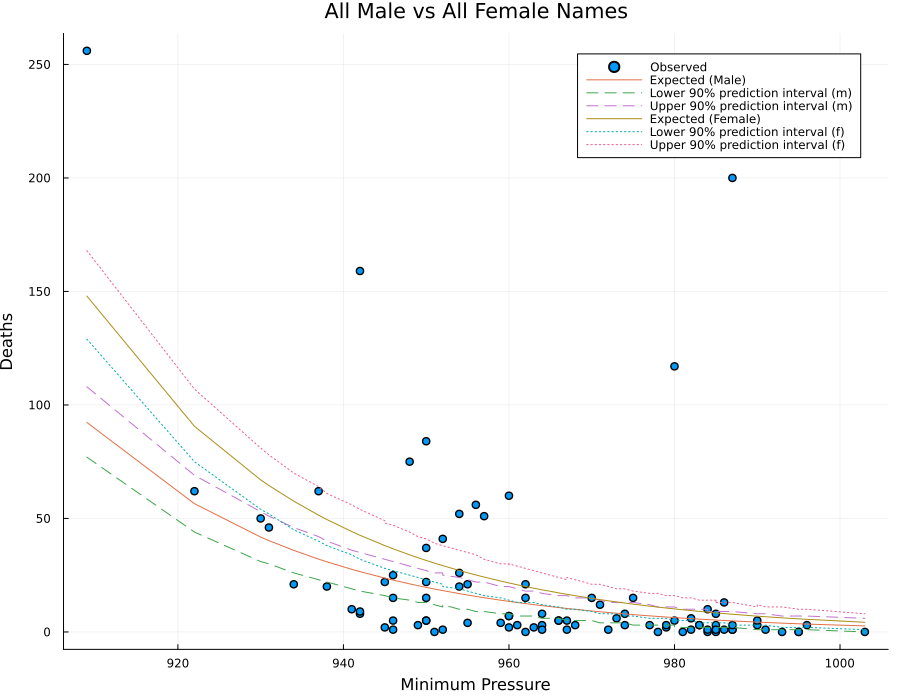

In [92]:
#Problem 4.2

h_male = copy(hurricane)
h_male.female .= 0

h_female = copy(hurricane)
h_female.female .= 1

pred_male   = predict(model_h2, h_male)
pred_female = predict(model_h2, h_female)

n_sim = 10000

#simulate 10000 counterfactuals

sim_male   = [rand(Poisson(pred_male[i]), n_sim) for i in 1:length(pred_male)]
sim_female = [rand(Poisson(pred_female[i]), n_sim) for i in 1:length(pred_female)]

#prediction intervals

lower_m = [quantile(sim_male[i], 0.05) for i in 1:length(pred_male)]
upper_m = [quantile(sim_male[i], 0.95) for i in 1:length(pred_male)]

lower_f = [quantile(sim_female[i], 0.05) for i in 1:length(pred_female)]
upper_f = [quantile(sim_female[i], 0.95) for i in 1:length(pred_female)]


#Sort for better plotting

sort_h = sortperm(hurricane.min_pressure)

pressure_sorted = hurricane.min_pressure[sort_h]
deaths_observed = hurricane.deaths[sort_h]

#Plot code

scatter(pressure_sorted, deaths_observed, xlabel = "Minimum Pressure", ylabel = "Deaths", 
title = "All Male vs All Female Names", label = "Observed", size = (900, 700))

plot!(pressure_sorted, pred_male[sort_h], 
    label = "Expected (Male)")
plot!(pressure_sorted, lower_m[sort_h], 
    linestyle =:dash, label = "Lower 90% prediction interval (m)")
plot!(pressure_sorted, upper_m[sort_h], 
    linestyle =:dash, label = "Upper 90% prediction interval (m)")

plot!(pressure_sorted, pred_female[sort_h], 
    label = "Expected (Female)")
plot!(pressure_sorted, lower_f[sort_h], 
    linestyle =:dot, label = "Lower 90% prediction interval (f)")
plot!(pressure_sorted, upper_f[sort_h], 
    linestyle =:dot, label = "Upper 90% prediction interval (f)")

In [93]:
#Problem 4.3 additional glm to show interaction between female and pressure_std
glm(@formula(deaths ~ female * pressure_std), hurricane, Poisson(), LogLink())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Poisson{Float64}, LogLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

deaths ~ 1 + female + pressure_std + female & pressure_std

Coefficients:
─────────────────────────────────────────────────────────────────────────────────────
                            Coef.  Std. Error       z  Pr(>|z|)  Lower 95%  Upper 95%
─────────────────────────────────────────────────────────────────────────────────────
(Intercept)             2.39505     0.0605154   39.58    <1e-99   2.27644    2.51366
female                  0.496871    0.0685134    7.25    <1e-12   0.362587   0.631155
pressure_std           -0.74665     0.0493415  -15.13    <1e-51  -0.843358  -0.649943
female & pressure_std   0.0337507   0.0550208    0.61    0.5396  -0.074088   0.141589
─────────────────────────────────────────────────────────────────────────────────────

Problem 4.2

Based on the results shown in the plot above, the model does well at predicting lower to moderate death counts.  The expected value for both female-named and male-named storms, as well as their respective 90% predictive interval, are pretty reasonable based on the observed death counts for storms.  The model does not do well for storms that have high death counts.  The model clearly shows some weakness in this regard and is much better at producing predictions for higher minimum pressure and lower death count storms.


Problem 4.3

The female predictor coefficient was calculated to be 0.472 and e^0.472 gives the rate ratio which is ~1.603.  This implies that, given minimum pressure is constant among a female and male-named storm, that the death count from the female-named storm is predicted to be ~60% higher than the male-named storm.

This is quite a large difference in death count for simply just the gender of the storm name.  Despite the P-value being less than 0.05, indicating this is a statistical significant result, I think it is far more logical and reasonable to conclude that there are other factors at play here and that the gendered name given to a hurricane does not result in a 60% greater death toll.

Additionally, running another GLM that accounts for the interaction between the predictors female and pressure_std, there does not appear to be evidence that the gender effect changes based on the storm strength.  This can be seen in the female and pressure_std P value being 0.5396, well above the 0.05, showing no statistical significance.


Problem 4.4

Based on some preliminary exploratory analysis of the data below, I think that a reasonable amount of the finding is just an artifact of the dataset.  This is for a multitude of reasons, the first being that the mean is considerably larger than the median.  This is a sign that the data might be skewed and that outliers could be influencing results.  To investigate this further, I plotted a histogram that very clearly shows a prominant right skew.  I also looked at the mean of female and male-named storms individually and female was also notably higher as well.  This leads me to beleive that the data is heavily impacted by the three largest storms by death count are all female (Camille, Diane, and Sandy) and while there may be something to be said about a lack of preparedness, and other factors that result from gendered storm names, I have a hard time thinking that this is more than, mainly, a somewhat small dataset being heavily skewed by three storms.


20.652173913043477
5.0
23.758064516129032
14.233333333333333

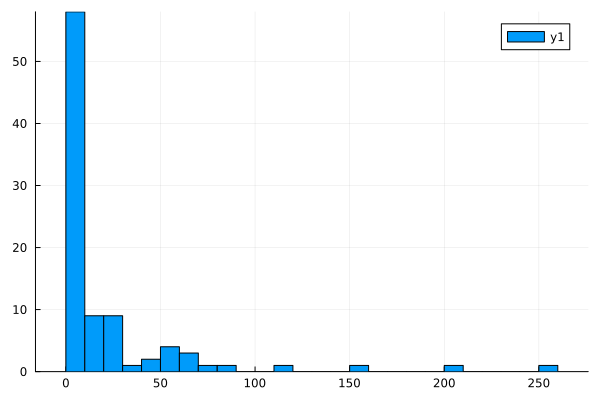

In [94]:
#Problem 4.4

#Stats code and plot code
h_mean = mean(hurricane.deaths)
println(h_mean)

h_med = median(hurricane.deaths)
println(h_med)

f_mean = mean(hurricane.deaths[hurricane.female .== 1])
println(f_mean)
m_mean = mean(hurricane.deaths[hurricane.female .== 0])
print(m_mean)

histogram(hurricane.deaths)

## References

[1] This paper has become a bit of a joke among statisticians, but let’s
take the hypothesis seriously for this problem’s sake.

References part 2:

OpenAI. (2024). ChatGPT (Sept 25 GPT-5 version) [Large language model].
https://chat.openai.com:  I utilized ChatGPT to help specifically with preliminary code development and some julia-specific syntax guidance.  The ideas behind the code formulation and the analysis was all done by me.